# 3. Model Training

**Models:**
1. k-NN (k=5)
2. k-NN (k=15)
3. MLP (1 hidden layer, 64 neurons)
4. MLP (2 hidden layers, 32 neurons each)
5. MLP (1 hidden layer, 128 neurons, with dropout)

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import roc_auc_score, make_scorer
import joblib
import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping

# Config
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

## 3.1 Load Data

In [8]:
trainval = pd.read_csv('data/TRAINVAL_scaled.csv')
print(f"TRAINVAL: {trainval.shape}")

trainval_sub = pd.read_csv('data/TRAINVAL_subsample.csv')
print(f"TRAINVAL subsample: {trainval_sub.shape}")

TRAINVAL: (30160, 4007)
TRAINVAL subsample: (3016, 4007)


In [9]:
feature_cols = [c for c in trainval.columns if c.startswith('feat_')]

X_train = trainval[feature_cols].values
y_train = trainval['ml_target'].values

X_train_sub = trainval_sub[feature_cols].values
y_train_sub = trainval_sub['ml_target'].values

print(f"Full: X={X_train.shape}, y={y_train.shape}")
print(f"Subsample: X={X_train_sub.shape}, y={y_train_sub.shape}")

Full: X=(30160, 4005), y=(30160,)
Subsample: X=(3016, 4005), y=(3016,)


## 3.2 Model 1: k-NN (k=5)

In [10]:
knn_k5 = KNeighborsClassifier(n_neighbors=5, weights='distance', n_jobs=-1)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
scores = cross_val_score(knn_k5, X_train_sub, y_train_sub, cv=cv, scoring='roc_auc')
print(f"CV AUC on subsample: {scores.mean():.4f} (+/- {scores.std():.4f})")

knn_k5.fit(X_train, y_train)

os.makedirs('models', exist_ok=True)
joblib.dump(knn_k5, 'models/knn_k5.pkl')
print("Saved: models/knn_k5.pkl")

CV AUC on subsample: 0.7179 (+/- 0.0496)
Saved: models/knn_k5.pkl


## 3.3 Model 2: k-NN (k=15)

In [11]:
knn_k15 = KNeighborsClassifier(n_neighbors=15, weights='distance', n_jobs=-1)

scores = cross_val_score(knn_k15, X_train_sub, y_train_sub, cv=cv, scoring='roc_auc')
print(f"CV AUC on subsample: {scores.mean():.4f} (+/- {scores.std():.4f})")

knn_k15.fit(X_train, y_train)

joblib.dump(knn_k15, 'models/knn_k15.pkl')
print("Saved: models/knn_k15.pkl")

CV AUC on subsample: 0.7092 (+/- 0.0266)
Saved: models/knn_k15.pkl


## 3.4 Model 3: MLP (1 layer, 64 neurons)

In [12]:
def build_mlp_v1(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=[tf.keras.metrics.AUC(name='auc')]
    )
    return model

mlp_v1 = build_mlp_v1(X_train.shape[1])
mlp_v1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │       256,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 256,449 (1001.75 KB)

 Trainable params: 256,449 (1001.75 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_v1 = mlp_v1.fit(
    X_train, y_train,
    epochs=50,
    batch_size=256,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

mlp_v1.save('models/mlp_1layer_64.keras')
print("Saved: models/mlp_1layer_64.keras")

Epoch 1/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - auc: 0.7176 - loss: 0.8879 - val_auc: 0.8642 - val_loss: 0.5776
Epoch 2/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - auc: 0.9234 - loss: 0.4018 - val_auc: 0.8730 - val_loss: 0.4841
Epoch 3/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - auc: 0.9602 - loss: 0.3097 - val_auc: 0.8782 - val_loss: 0.4733
Epoch 4/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - auc: 0.9756 - loss: 0.2641 - val_auc: 0.8786 - val_loss: 0.4787
Epoch 5/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - auc: 0.9833 - loss: 0.2338 - val_auc: 0.8776 - val_loss: 0.4887
Epoch 6/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - auc: 0.9877 - loss: 0.2117 - val_auc: 0.8755 - val_loss: 0.5039
Epoch 7/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - auc: 0.9902 - loss: 0.1965 - val_auc: 0.8743 - val_loss: 0.5142
Epoch 8/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - auc: 0.9931 - loss: 0.1772 - val_auc: 0.8733 - val_loss: 0.5273
Saved: models/mlp_1layer_64.keras


## 3.5 Model 4: MLP (2 layers, 32 neurons each)

In [14]:
def build_mlp_v2(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=[tf.keras.metrics.AUC(name='auc')]
    )
    return model

mlp_v2 = build_mlp_v2(X_train.shape[1])
mlp_v2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 32)             │       128,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 129,281 (505.00 KB)

 Trainable params: 129,281 (505.00 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
history_v2 = mlp_v2.fit(
    X_train, y_train,
    epochs=50,
    batch_size=256,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

mlp_v2.save('models/mlp_2layer_32.keras')
print("Saved: models/mlp_2layer_32.keras")

Epoch 1/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - auc: 0.6861 - loss: 0.6867 - val_auc: 0.8801 - val_loss: 0.4439
Epoch 2/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - auc: 0.9268 - loss: 0.3761 - val_auc: 0.8852 - val_loss: 0.4340
Epoch 3/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - auc: 0.9600 - loss: 0.3005 - val_auc: 0.8829 - val_loss: 0.4539
Epoch 4/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - auc: 0.9740 - loss: 0.2571 - val_auc: 0.8793 - val_loss: 0.4834
Epoch 5/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - auc: 0.9828 - loss: 0.2240 - val_auc: 0.8744 - val_loss: 0.5248
Epoch 6/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - auc: 0.9887 - loss: 0.1954 - val_auc: 0.8686 - val_loss: 0.5730
Epoch 7/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - auc: 0.9928 - loss: 0.1710 - val_auc: 0.8653 - val_loss: 0.6248
Saved: models/mlp_2layer_32.keras


## 3.6 Model 5: MLP (1 layer, 128 neurons, dropout)

In [16]:
def build_mlp_v3(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=[tf.keras.metrics.AUC(name='auc')]
    )
    return model

mlp_v3 = build_mlp_v3(X_train.shape[1])
mlp_v3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 128)            │       512,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 512,897 (1.96 MB)

 Trainable params: 512,897 (1.96 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
history_v3 = mlp_v3.fit(
    X_train, y_train,
    epochs=50,
    batch_size=256,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

mlp_v3.save('models/mlp_1layer_128_dropout.keras')
print("Saved: models/mlp_1layer_128_dropout.keras")

Epoch 1/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - auc: 0.6959 - loss: 0.8858 - val_auc: 0.8609 - val_loss: 0.4409
Epoch 2/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - auc: 0.8988 - loss: 0.3680 - val_auc: 0.8707 - val_loss: 0.4224
Epoch 3/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - auc: 0.9461 - loss: 0.2557 - val_auc: 0.8705 - val_loss: 0.4398
Epoch 4/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - auc: 0.9655 - loss: 0.2093 - val_auc: 0.8690 - val_loss: 0.4648
Epoch 5/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - auc: 0.9769 - loss: 0.1747 - val_auc: 0.8668 - val_loss: 0.4943
Epoch 6/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - auc: 0.9827 - loss: 0.1552 - val_auc: 0.8651 - val_loss: 0.5249
Epoch 7/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - auc: 0.9873 - loss: 0.1347 - val_auc: 0.8615 - val_loss: 0.5656
Saved: models/mlp_1layer_128_dropout.keras


## 3.7 Training Summary

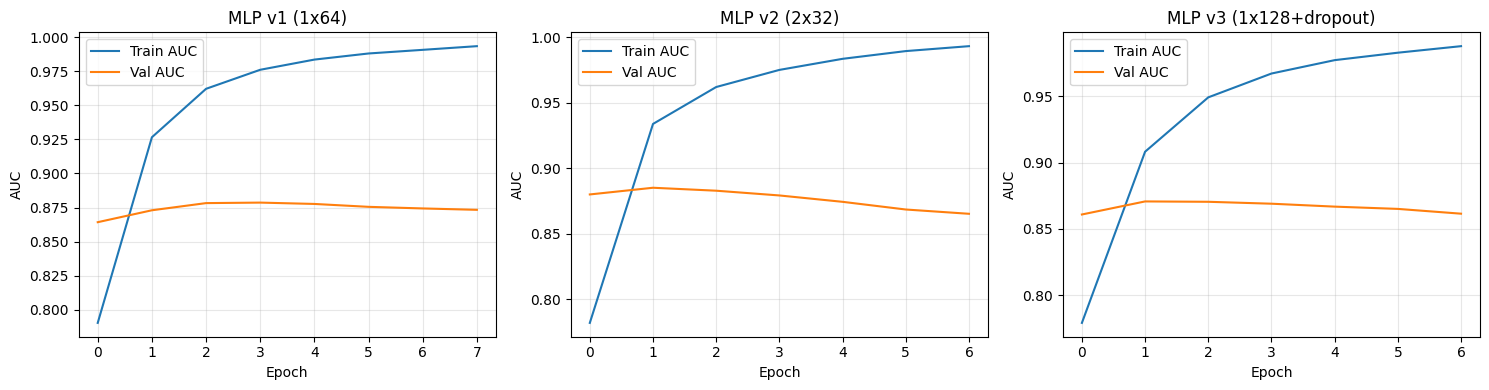

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

histories = [history_v1, history_v2, history_v3]
titles = ['MLP v1 (1x64)', 'MLP v2 (2x32)', 'MLP v3 (1x128+dropout)']

for ax, hist, title in zip(axes, histories, titles):
    auc_key = next((k for k in hist.history.keys() if 'auc' in k.lower() and 'val' not in k), 'auc')
    val_auc_key = next((k for k in hist.history.keys() if 'auc' in k.lower() and 'val' in k), 'val_auc')

    ax.plot(hist.history[auc_key], label='Train AUC')
    ax.plot(hist.history[val_auc_key], label='Val AUC')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('AUC')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()